# E-commerce-Sales-and-Customers-RFM-Analysis


## SQL Environment Setup

### Install Compatible Packages

In [ ]:
# Remove potentially incompatible versions
!pip uninstall -y ipython-sql prettytable

# Install compatible versions
!pip install ipython-sql==0.5.0
!pip install prettytable==3.10.0 openpyxl

Found existing installation: ipython-sql 0.5.0
Uninstalling ipython-sql-0.5.0:
  Successfully uninstalled ipython-sql-0.5.0
Found existing installation: prettytable 3.17.0
Uninstalling prettytable-3.17.0:
  Successfully uninstalled prettytable-3.17.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.5 MB/s eta 0:00:00
  Attempting uninstall: prettytable
    Found existing installation: prettytable 3.17.0
    Uninstalling prettytable-3.17.0:
      Successfully uninstalled prettytable-3.17.0


### Import SQL & prettytable

In [ ]:
import sql
import prettytable



### Load SQL Extension

In [ ]:
%load_ext sql

### Upload dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail Cleaned.csv to Online Retail Cleaned.csv


### Load data into SQLite

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Read CSV file with 'latin1' encoding to handle UnicodeDecodeError
df = pd.read_csv("/content/Online Retail Cleaned.csv", encoding='latin1')

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create SQLite database
conn = sqlite3.connect("my_data.db")

# Write dataframe to SQL table
df.to_sql(
    "online_sales",
    conn,
    index=False,
    if_exists="replace"
)

print("Data uploaded successfully!")
print("Shape:", df.shape)

Data uploaded successfully!
Shape: (534131, 12)


### Connect SQL Magic

In [ ]:
%sql sqlite:///my_data.db

### Check and test query

In [ ]:
%%sql

SELECT name
FROM sqlite_master
WHERE type='table';

 * sqlite:///my_data.db
Done.


name
online_sales


In [ ]:
%%sql

SELECT *
FROM online_sales
LIMIT 10;

## Data Quality Assessment

In [ ]:
# Checking Datatype

%%sql

PRAGMA table_info(online_sales);

 * sqlite:///my_data.db
Done.


cid,name,type,notnull,dflt_value,pk
0,InvoiceNo,TEXT,0,None,0
1,StockCode,TEXT,0,None,0
2,Description,TEXT,0,None,0
3,Quantity,INTEGER,0,None,0
4,TransactionType,TEXT,0,None,0
5,InvoiceDate,TIMESTAMP,0,None,0
6,InvoiceTime,TEXT,0,None,0
7,UnitPrice,REAL,0,None,0
8,Revenue,REAL,0,None,0
9,CustomerID,REAL,0,None,0


In [ ]:
# How many transaction in this dataset?

%%sql

SELECT COUNT(*)
FROM online_sales;

 * sqlite:///my_data.db
Done.


COUNT(*)
534131


In [ ]:
# Checking InvoiceNo, detecting outliers

%%sql

SELECT
MAX(LENGTH(InvoiceNo)) AS max_length,
MIN(LENGTH(InvoiceNo)) AS min_length,
ROUND(AVG(LENGTH(InvoiceNo)),2) AS avg_length
FROM online_sales;

 * sqlite:///my_data.db
Done.


max_length,min_length,avg_length
7,6,6.02


In [ ]:
## Checking InvoiceNo length greater than 6
# -- Invoice number greater than length of 6 are actually cancelled orders and they include "C" infront of the invoice number.

%%sql

SELECT *
FROM online_sales
WHERE LENGTH(InvoiceNo) > 6
LIMIT 10;


 * sqlite:///my_data.db
Done.


InvoiceNo,StockCode,Description,Quantity,TransactionType,InvoiceDate,InvoiceTime,UnitPrice,Revenue,CustomerID,CustomerType,Country
C536379,D,Discount,-1,Return,12/1/2010,9:41:00 AM,27.5,-27.5,14527.0,Registered,United Kingdom
C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,Return,12/1/2010,9:49:00 AM,4.65,-4.65,15311.0,Registered,United Kingdom
C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,Return,12/1/2010,10:24:00 AM,1.65,-19.8,17548.0,Registered,United Kingdom
C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,Return,12/1/2010,10:24:00 AM,0.29,-6.96,17548.0,Registered,United Kingdom
C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,Return,12/1/2010,10:24:00 AM,0.29,-6.96,17548.0,Registered,United Kingdom
C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,Return,12/1/2010,10:24:00 AM,0.29,-6.96,17548.0,Registered,United Kingdom
C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,Return,12/1/2010,10:24:00 AM,3.45,-41.4,17548.0,Registered,United Kingdom
C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,Return,12/1/2010,10:24:00 AM,1.65,-19.8,17548.0,Registered,United Kingdom
C536391,22553,PLASTERS IN TIN SKULLS,-24,Return,12/1/2010,10:24:00 AM,1.65,-39.6,17548.0,Registered,United Kingdom
C536506,22960,JAM MAKING SET WITH JARS,-6,Return,12/1/2010,12:38:00 PM,4.25,-25.5,17897.0,Registered,United Kingdom


In [ ]:
# Checking StockCode, detecting outliers

%%sql

SELECT
MAX(LENGTH(StockCode)) AS max_length,
MIN(LENGTH(StockCode)) AS min_length,
ROUND(AVG(LENGTH(StockCode)),2) AS avg_length
FROM online_sales;

 * sqlite:///my_data.db
Done.


max_length,min_length,avg_length
12,1,5.09


In [ ]:
## Checking StockCode suspected data

%%sql

SELECT *
FROM online_sales
WHERE LENGTH(StockCode) > 5 OR LENGTH(StockCode) < 5
LIMIT 10;

 * sqlite:///my_data.db
Done.


InvoiceNo,StockCode,Description,Quantity,TransactionType,InvoiceDate,InvoiceTime,UnitPrice,Revenue,CustomerID,CustomerType,Country
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,Sale,12/1/2010,8:26:00 AM,2.55,15.3,17850.0,Registered,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,Sale,12/1/2010,8:26:00 AM,2.75,22.0,17850.0,Registered,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,Sale,12/1/2010,8:26:00 AM,3.39,20.34,17850.0,Registered,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,Sale,12/1/2010,8:26:00 AM,3.39,20.34,17850.0,Registered,United Kingdom
536370,POST,POSTAGE,3,Sale,12/1/2010,8:45:00 AM,18.0,54.0,12583.0,Registered,France
536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,Sale,12/1/2010,9:02:00 AM,2.55,15.3,17850.0,Registered,United Kingdom
536373,84406B,CREAM CUPID HEARTS COAT HANGER,8,Sale,12/1/2010,9:02:00 AM,2.75,22.0,17850.0,Registered,United Kingdom
536373,82494L,WOODEN FRAME ANTIQUE WHITE,6,Sale,12/1/2010,9:02:00 AM,2.55,15.3,17850.0,Registered,United Kingdom
536373,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,Sale,12/1/2010,9:02:00 AM,3.39,20.34,17850.0,Registered,United Kingdom
536373,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,Sale,12/1/2010,9:02:00 AM,3.39,20.34,17850.0,Registered,United Kingdom


In [ ]:
# How many stock Codes?

%%sql

SELECT COUNT(*)
FROM
  (
    SELECT DISTINCT StockCode
    FROM online_sales
  );

 * sqlite:///my_data.db
Done.


COUNT(*)
3938


In [ ]:
# How many distinct description?

%%sql

SELECT COUNT(*)
FROM
  (
    SELECT DISTINCT Description
    FROM online_sales
  );


 * sqlite:///my_data.db
Done.


COUNT(*)
4031


In [ ]:
# Quantity Distribution

df['Quantity'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

,Quantity
count,534131.000000
mean,9.916784
std,216.451709
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
90%,24.000000
95%,30.000000
99%,100.000000


In [ ]:
# Max, Min and Average of Quantity
# Is 80995 and -80995 are limits?

%%sql

SELECT
MAX(Quantity) AS max_quantity,
MIN(Quantity) AS min_quantity,
AVG(Quantity) AS avg_quantity
FROM online_sales;

 * sqlite:///my_data.db
Done.


max_quantity,min_quantity,avg_quantity
80995,-80995,9.916784459243145


In [ ]:
## Checking extreme Quantity data
## -- Found that there is only one customer who ordered paper craft, ordered 80995 items and cancelled the order after 12 mins.

%%sql

SELECT *
FROM online_sales
WHERE Quantity = 80995 or Quantity = -80995;

 * sqlite:///my_data.db
Done.


InvoiceNo,StockCode,Description,Quantity,TransactionType,InvoiceDate,InvoiceTime,UnitPrice,Revenue,CustomerID,CustomerType,Country
581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,Sale,12/9/2011,9:15:00 AM,2.08,168469.6,16446.0,Registered,United Kingdom
C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,Return,12/9/2011,9:27:00 AM,2.08,-168469.6,16446.0,Registered,United Kingdom


In [ ]:
## Total Positive Quantity Sold

%%sql

SELECT SUM(Quantity) AS total_quantity
FROM online_sales
WHERE Quantity > 0;

 * sqlite:///my_data.db
Done.


total_quantity
5572422


In [ ]:
# How many orders are cancelled?

%%sql

SELECT COUNT(*)
FROM online_sales
WHERE Quantity < 0;

 * sqlite:///my_data.db
Done.


COUNT(*)
9251


In [ ]:
# Explore TransactionType

%%sql

SELECT DISTINCT TransactionType
FROM online_sales;

 * sqlite:///my_data.db
Done.


TransactionType
Sale
Return


In [ ]:
# Explore timeline
# How many years of sales area avaiable

%%sql

SELECT
    MIN(InvoiceDate) AS start_date,
    MAX(InvoiceDate) AS end_date,
    (
        (CAST(strftime('%Y', MAX(InvoiceDate)) AS INTEGER) -
         CAST(strftime('%Y', MIN(InvoiceDate)) AS INTEGER)) * 12
        +
        (CAST(strftime('%m', MAX(InvoiceDate)) AS INTEGER) -
         CAST(strftime('%m', MIN(InvoiceDate)) AS INTEGER))
    ) AS order_range_months
FROM online_sales;


 * sqlite:///my_data.db
Done.


start_date,end_date,order_range_months
2010-12-01 00:00:00,2011-12-09 00:00:00,12


In [ ]:
# Explore UnitPrice

%%sql

SELECT
MAX(UnitPrice) AS max_price,
MIN(UnitPrice) AS min_price,
AVG(UnitPrice) AS avg_price
FROM online_sales;

 * sqlite:///my_data.db
Done.


max_price,min_price,avg_price
38970.0,-11062.06,4.654425543541132


In [ ]:
# UnitPrice Distribution

df['UnitPrice'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

,UnitPrice
count,534131.000000
mean,4.654426
std,97.460790
min,-11062.060000
25%,1.250000
50%,2.100000
75%,4.130000
90%,7.950000
95%,9.950000
99%,18.000000


In [ ]:
# Explore Extreme Unitprice

%%sql

SELECT *
FROM online_sales
WHERE UnitPrice = 38970;

 * sqlite:///my_data.db
Done.


InvoiceNo,StockCode,Description,Quantity,TransactionType,InvoiceDate,InvoiceTime,UnitPrice,Revenue,CustomerID,CustomerType,Country
C556445,M,Manual,-1,Return,2011-06-10 00:00:00,3:31:00 AM,38970.0,-38970.0,15098.0,Registered,United Kingdom


In [ ]:
# Explore negative UnitPrice
# 2 Adjust bad debt on 2011-08-12 same time.

%%sql

SELECT *
FROM online_sales
WHERE UnitPrice < 0
LIMIT 10;

 * sqlite:///my_data.db
Done.


InvoiceNo,StockCode,Description,Quantity,TransactionType,InvoiceDate,InvoiceTime,UnitPrice,Revenue,CustomerID,CustomerType,Country
A563186,B,Adjust bad debt,1,Sale,2011-08-12 00:00:00,2:51:00 AM,-11062.06,-11062.06,None,Guest,United Kingdom
A563187,B,Adjust bad debt,1,Sale,2011-08-12 00:00:00,2:52:00 AM,-11062.06,-11062.06,None,Guest,United Kingdom


In [ ]:
# Explore Revenue

%%sql

SELECT
MIN(Revenue) AS min_revenue,
MAX(Revenue) AS max_revenue,
ROUND(SUM(Revenue),2) AS total_sales
FROM online_sales
WHERE Revenue > 0;

 * sqlite:///my_data.db
Done.


min_revenue,max_revenue,total_sales
0.06,168469.6,10642110.8


In [ ]:
# Revenue Distribution

df['Revenue'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

,Revenue
count,534131.000000
mean,18.209029
std,381.547578
min,-168469.600000
25%,3.750000
50%,9.900000
75%,17.570000
90%,31.980000
95%,59.400000
99%,182.600000


In [ ]:
# Explore CustomerID

%%sql

SELECT
MIN(LENGTH(CAST(CustomerID AS VARCHAR))) AS min_length_customerID,
MAX(LENGTH(CAST(CustomerID AS VARCHAR))) AS max_length_customerID
FROM online_sales;

 * sqlite:///my_data.db
Done.


min_length_customerID,max_length_customerID
7,7


In [ ]:
# Explore customer type

%%sql
SELECT DISTINCT CustomerType
FROM online_sales;

 * sqlite:///my_data.db
Done.


CustomerType
Registered
Guest


In [ ]:
# Explore all the countries customers are from

%%sql

SELECT DISTINCT Country
FROM online_sales;




 * sqlite:///my_data.db
Done.


Country
United Kingdom
France
Australia
Netherlands
Germany
Norway
EIRE
Switzerland
Spain
Poland


## EDA

In [ ]:
# What is total Sales

%%sql

SELECT
ROUND(SUM(Revenue),2) AS total_sales
FROM online_sales
WHERE Revenue > 0;

 * sqlite:///my_data.db
Done.


total_sales
10642110.8


In [ ]:
# Sales trend

%%sql

SELECT
strftime('%Y-%m', InvoiceDate) AS year_month,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
WHERE Quantity > 0 AND UnitPrice > 0
GROUP BY year_month
ORDER BY year_month;




 * sqlite:///my_data.db
Done.


year_month,total_revenue
2010-12,821452.73
2011-01,689811.61
2011-02,522545.56
2011-03,716215.26
2011-04,536968.49
2011-05,769296.61
2011-06,760547.01
2011-07,718076.12
2011-08,757841.38
2011-09,1056435.19


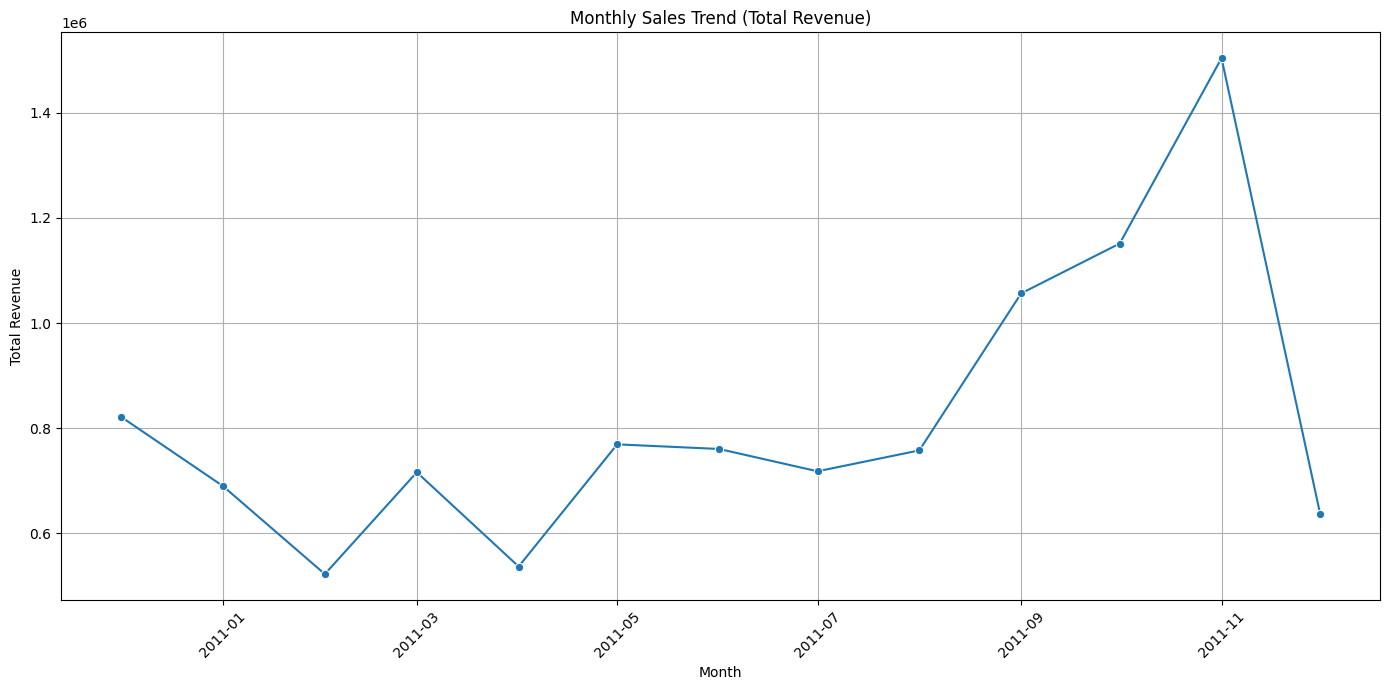

In [ ]:
sales_trend_df = pd.read_sql_query(
    """SELECT
    strftime('%Y-%m', InvoiceDate) AS year_month,
    ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    WHERE Quantity > 0 AND UnitPrice > 0
    GROUP BY year_month
    ORDER BY year_month;""",
    conn
)

# Convert 'year_month' to datetime for proper plotting
sales_trend_df['year_month'] = pd.to_datetime(sales_trend_df['year_month'])

# Plot the sales trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=sales_trend_df, x='year_month', y='total_revenue', marker='o')
plt.title('Monthly Sales Trend (Total Revenue)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Monthly order trend

%%sql

SELECT
    strftime('%Y-%m', InvoiceDate) AS YearMonth,
    COUNT(DISTINCT InvoiceNo) AS TotalOrders
FROM online_sales
WHERE InvoiceNo NOT LIKE 'C%'
GROUP BY YearMonth
ORDER BY YearMonth;

 * sqlite:///my_data.db
Done.


YearMonth,TotalOrders
2010-12,1559
2011-01,1086
2011-02,1100
2011-03,1454
2011-04,1246
2011-05,1681
2011-06,1533
2011-07,1475
2011-08,1363
2011-09,1837


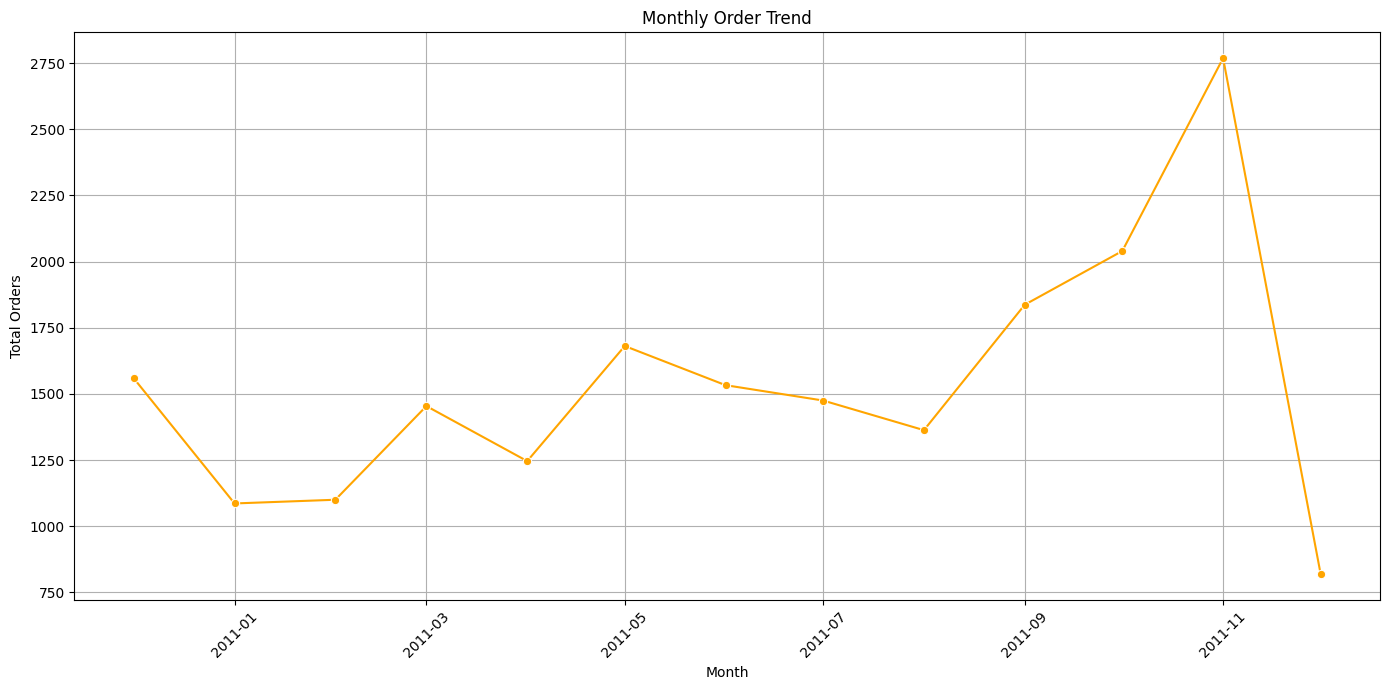

In [ ]:
monthly_order_trend_df = pd.read_sql_query(
    """SELECT
        strftime('%Y-%m', InvoiceDate) AS YearMonth,
        COUNT(DISTINCT InvoiceNo) AS TotalOrders
    FROM online_sales
    WHERE InvoiceNo NOT LIKE 'C%'
    GROUP BY YearMonth
    ORDER BY YearMonth;""",
    conn
)

# Convert 'YearMonth' to datetime for proper plotting
monthly_order_trend_df['YearMonth'] = pd.to_datetime(monthly_order_trend_df['YearMonth'])

# Plot the monthly order trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_order_trend_df, x='YearMonth', y='TotalOrders', marker='o', color='orange')
plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Monthly customer trend

%%sql

SELECT
    strftime('%Y-%m', InvoiceDate) AS YearMonth,
    COUNT(DISTINCT CustomerID) AS ActiveCustomers
FROM online_sales
WHERE CustomerID IS NOT NULL
    AND InvoiceNo NOT LIKE 'C%'
GROUP BY YearMonth
ORDER BY YearMonth;

 * sqlite:///my_data.db
Done.


YearMonth,ActiveCustomers
2010-12,885
2011-01,741
2011-02,758
2011-03,974
2011-04,856
2011-05,1056
2011-06,991
2011-07,949
2011-08,935
2011-09,1266


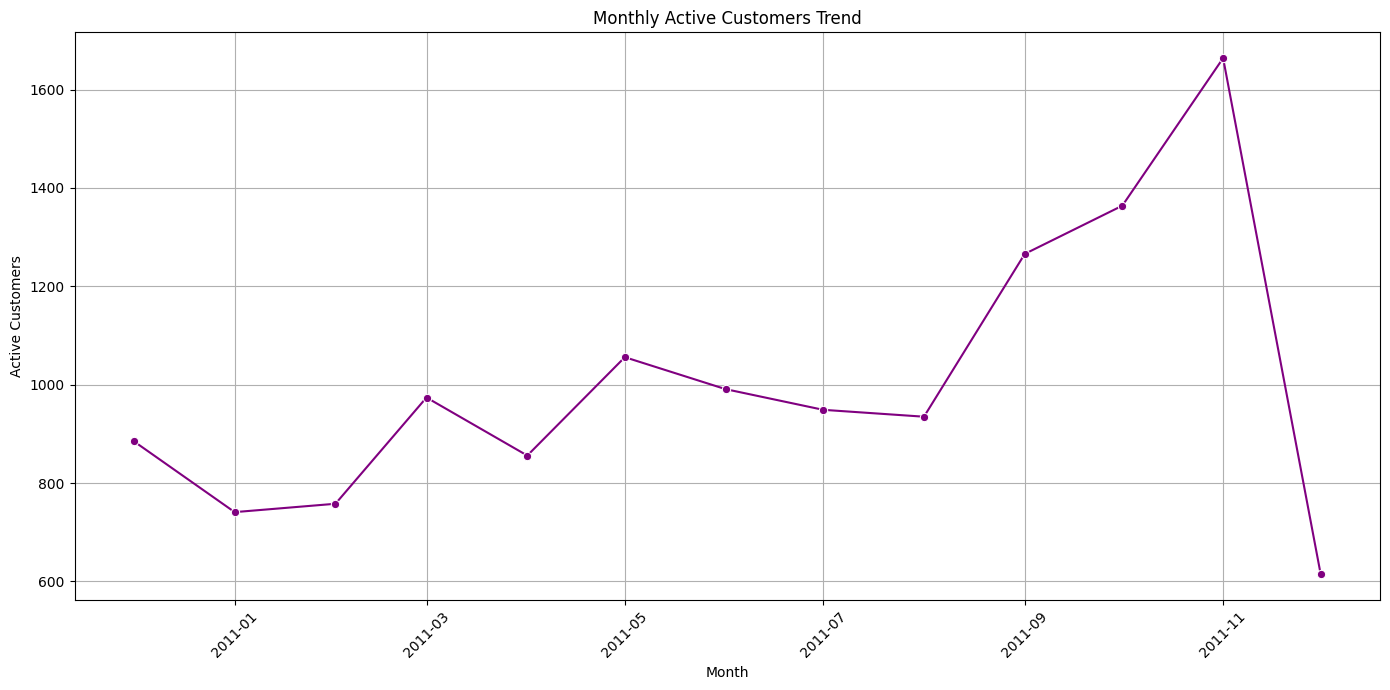

In [ ]:
monthly_customers_trend_df = pd.read_sql_query(
    """SELECT
        strftime('%Y-%m', InvoiceDate) AS YearMonth,
        COUNT(DISTINCT CustomerID) AS ActiveCustomers
    FROM online_sales
    WHERE CustomerID IS NOT NULL
        AND InvoiceNo NOT LIKE 'C%'
    GROUP BY YearMonth
    ORDER BY YearMonth;""",
    conn
)

# Convert 'YearMonth' to datetime for proper plotting
monthly_customers_trend_df['YearMonth'] = pd.to_datetime(monthly_customers_trend_df['YearMonth'])

# Plot the monthly customer trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_customers_trend_df, x='YearMonth', y='ActiveCustomers', marker='o', color='purple')
plt.title('Monthly Active Customers Trend')
plt.xlabel('Month')
plt.ylabel('Active Customers')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***Insights***

Beginning in September, sales accelerated significantly, reaching a peak of **£1.50 million** in November 2011. This pattern suggests **strong seasonality** and increased customer demand during the holiday shopping period. Same trends in orders, customers confirm the strong seasonality. The dataset contain only partial December data and the apparent decline in December should not be interpreted.

In [ ]:
# Sales by Product (Top 20)

%%sql

SELECT
Description,
ROUND(SUM(Revenue),2) AS total_reveune
FROM online_sales
GROUP BY Description
ORDER BY ROUND(SUM(Revenue),2) DESC
LIMIT 20;

 * sqlite:///my_data.db
Done.


Description,total_reveune
DOTCOM POSTAGE,206245.48
REGENCY CAKESTAND 3 TIER,164459.49
WHITE HANGING HEART T-LIGHT HOLDER,99612.42
PARTY BUNTING,98243.88
JUMBO BAG RED RETROSPOT,92175.79
RABBIT NIGHT LIGHT,66661.63
POSTAGE,66230.64
PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
ASSORTED COLOUR BIRD ORNAMENT,58792.42
CHILLI LIGHTS,53746.66


/tmp/ipykernel_12922/1408754897.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='Description', data=top_products_df, palette='viridis')


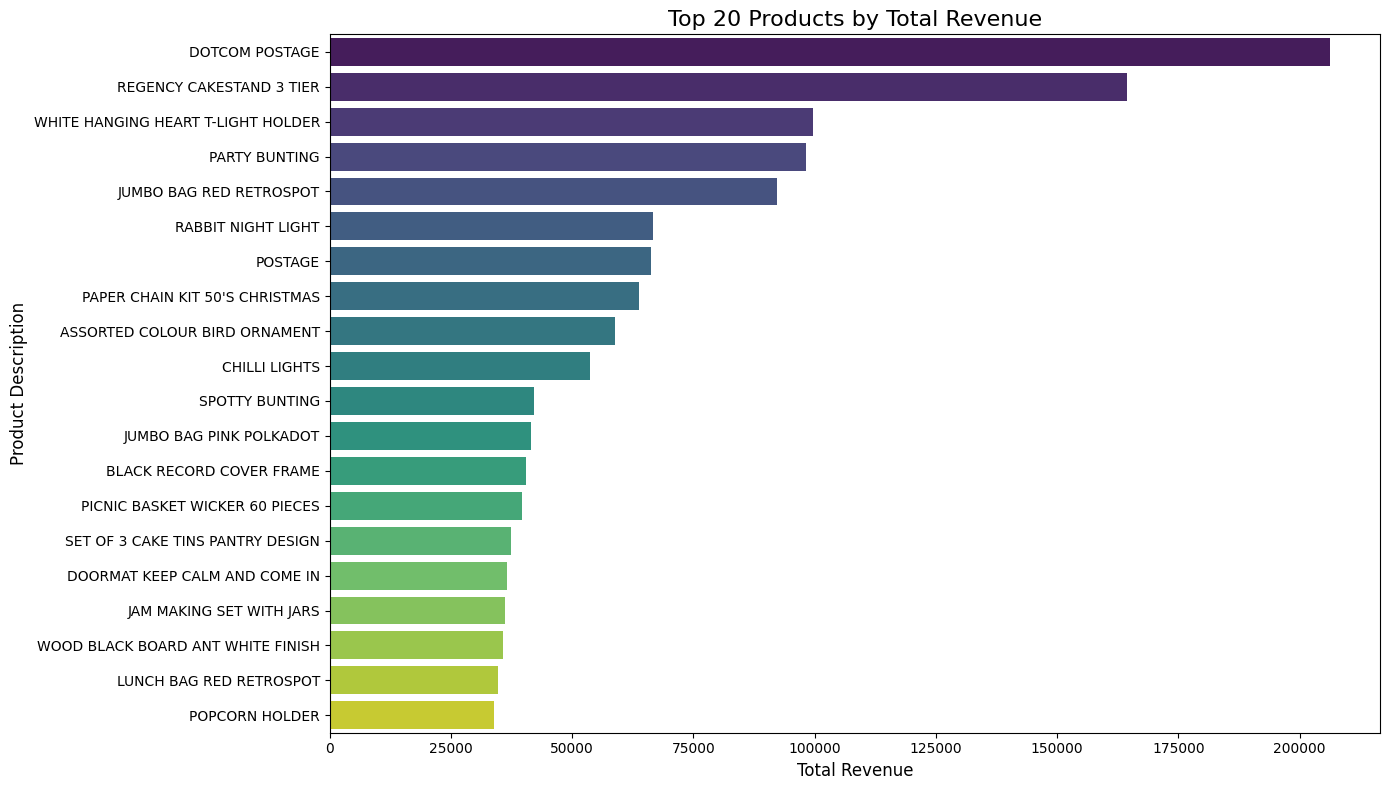

In [ ]:
top_products_df = pd.read_sql_query(
    """SELECT
    Description,
    ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    GROUP BY Description
    ORDER BY ROUND(SUM(Revenue),2) DESC
    LIMIT 20;""",
    conn
)


# Plotting the top 20 products by revenue
plt.figure(figsize=(14, 8))
sns.barplot(x='total_revenue', y='Description', data=top_products_df, palette='viridis')
plt.title('Top 20 Products by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()

***Insights***

* Many top selling products belong to Home Decor, Party & Celebration, Gift & Kitchenware and this suggests our customers are purchasing decorative and gifting products rather than necessities.
* The top product, `DOTCOM POSTAGE` generated **£206,245** and it shows shipping charges alone generated a substantial amount of revenue.


In [ ]:
# Sales by countries

%%sql

SELECT
Country,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
GROUP BY Country
ORDER BY SUM(Revenue) DESC;

 * sqlite:///my_data.db
Done.


Country,total_revenue
United Kingdom,8167128.18
Netherlands,284661.54
EIRE,262993.38
Germany,221509.47
France,197317.11
Australia,137009.77
Switzerland,56363.05
Spain,54756.03
Belgium,40910.96
Sweden,36585.41


/tmp/ipykernel_12922/3138374482.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='Country', data=sales_by_country_df, palette='viridis')


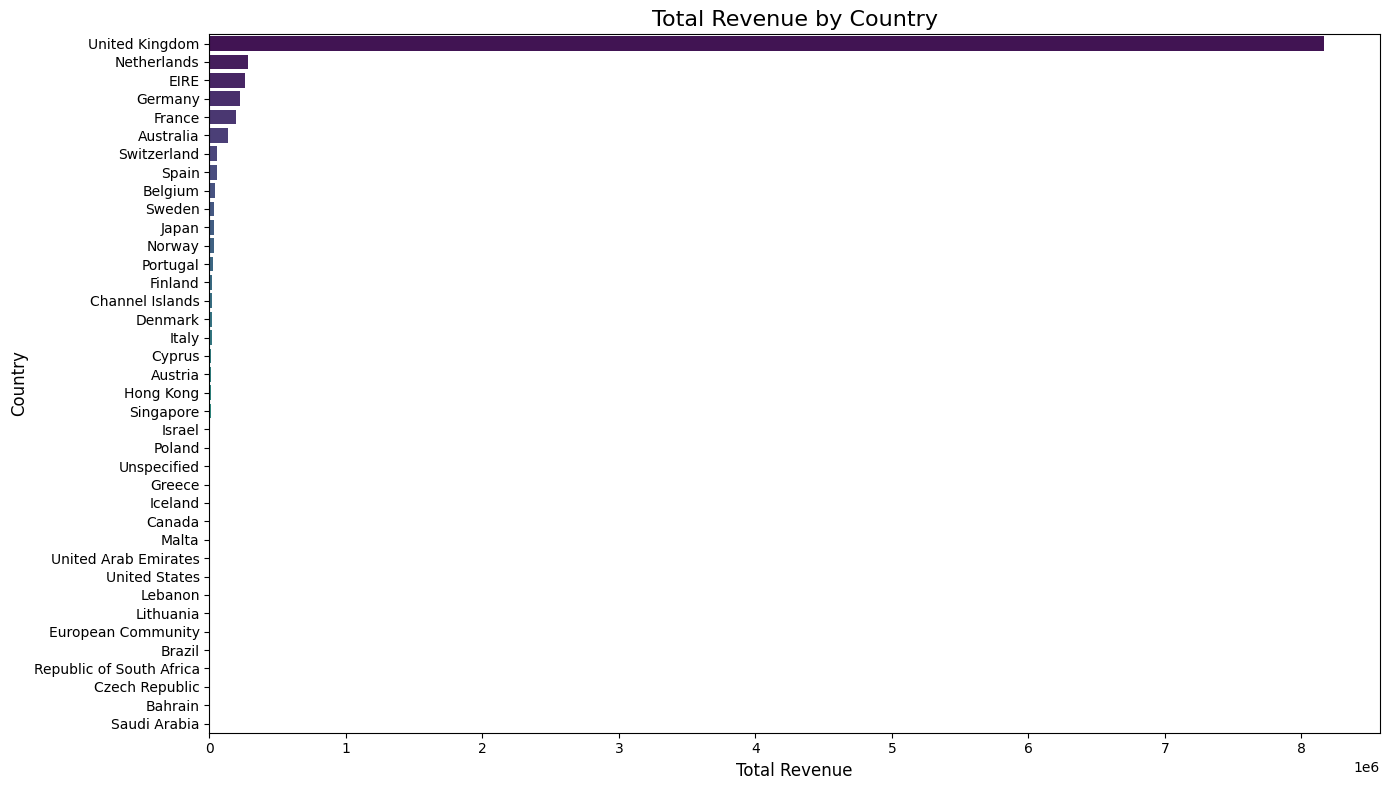

In [ ]:
sales_by_country_df = pd.read_sql_query(
    """SELECT
    Country,
    ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    GROUP BY Country
    ORDER BY SUM(Revenue) DESC;""",
    conn
)

# Plotting the sales by country
plt.figure(figsize=(14, 8))
sns.barplot(x='total_revenue', y='Country', data=sales_by_country_df, palette='viridis')
plt.title('Total Revenue by Country', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

***Insights***

The United Kingdom was the company's primary market, generating **£8.17 million** in revenue and accounting for approximately 84% of total sales. International markets contributed the remaining 16%, with the Netherlands, EIRE, Germany, France, and Australia emerging as the strongest performers.

In [ ]:
# Sales by customers

%%sql

SELECT
CustomerID,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
GROUP BY CustomerID
ORDER BY SUM(revenue) DESC
LIMIT 20;

 * sqlite:///my_data.db
Done.


CustomerID,total_revenue
None,1447487.53
14646.0,279489.02
18102.0,256438.49
17450.0,187322.17
14911.0,132458.73
12415.0,123725.45
14156.0,113214.59
17511.0,88125.38
16684.0,65892.08
13694.0,62690.54


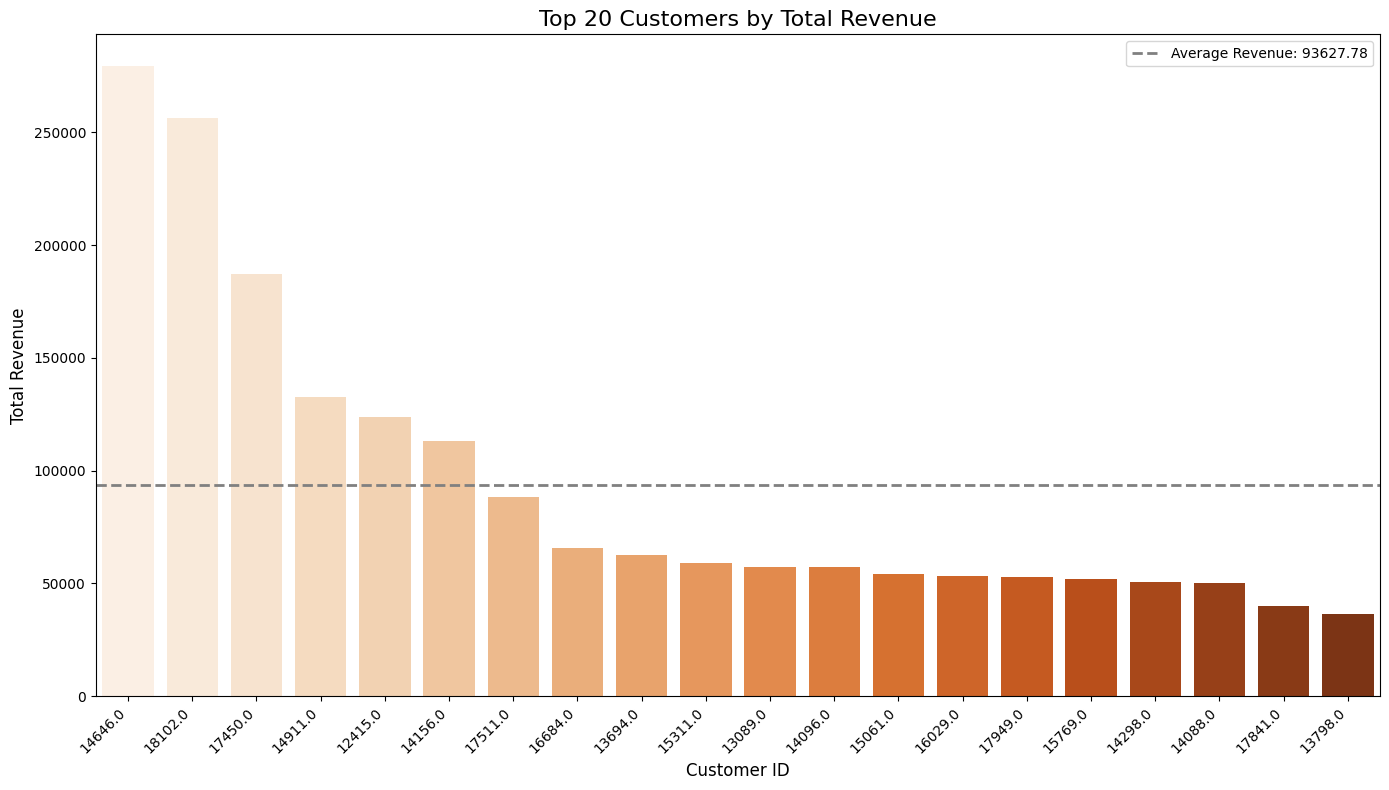

In [ ]:
customer_revenue_df = pd.read_sql_query(
    """SELECT
    CAST(CustomerID AS TEXT) AS CustomerID,
    ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    WHERE CustomerID IS NOT NULL
    GROUP BY CustomerID
    ORDER BY total_revenue DESC
    LIMIT 20;""",
    conn
)

# Plotting the top 20 customers by revenue
plt.figure(figsize=(14, 8))
sns.barplot(x='CustomerID', y='total_revenue', hue='CustomerID', data=customer_revenue_df, palette='Oranges', legend=False)

# Calculate the average revenue for the top 20 customers
average_revenue = customer_revenue_df['total_revenue'].mean()

# Add a horizontal line for the average revenue
plt.axhline(y=average_revenue, color='gray', linestyle='--', linewidth=2, label=f'Average Revenue: {average_revenue:.2f}')

plt.title('Top 20 Customers by Total Revenue', fontsize=16)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate CustomerID labels for better readability
plt.legend()
plt.tight_layout()
plt.show()

***Insights***

Customer revenue was highly concentrated among a small number of high-value customers. The highest-spending customer generated **£279K** in revenue, while several customers exceeded £100K in total purchases. The sharp decline in revenue beyond the top-ranked customers indicates a long-tail distribution, suggesting that a small proportion of customers contribute disproportionately to overall sales. This pattern may reflect the presence of wholesale or business buyers and highlights potential customer concentration risk. These findings support the need for further customer segmentation through RFM and retention analysis.

In [ ]:

# Sales by customer types

%%sql

SELECT
CustomerType,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
GROUP BY CustomerType;

 * sqlite:///my_data.db
Done.


CustomerType,total_revenue
Guest,1447487.53
Registered,8278519.42


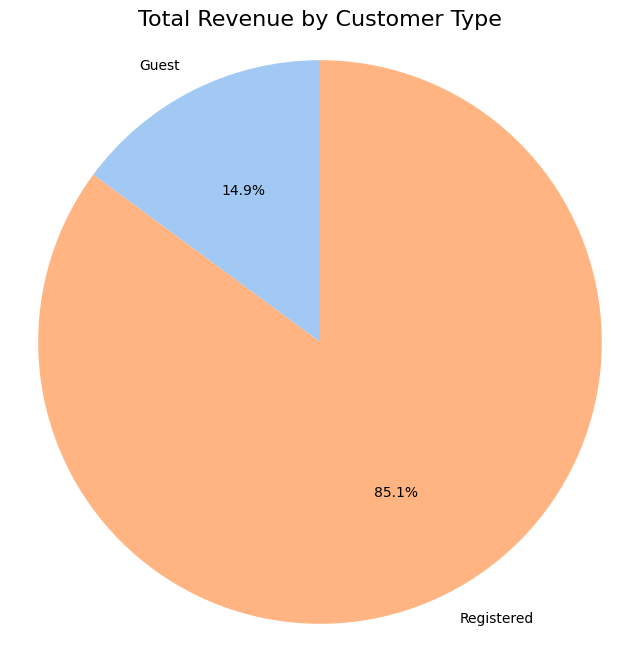

In [ ]:
customer_type_revenue_df = pd.read_sql_query(
    """SELECT
    CustomerType,
    ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    GROUP BY CustomerType;""",
    conn
)

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    customer_type_revenue_df['total_revenue'],
    labels=customer_type_revenue_df['CustomerType'],
    autopct='%1.1f%%', # Format for percentage labels
    startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Total Revenue by Customer Type', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

***Insights***

Registered customers generated **£8.28 million** in revenue, accounting for approximately 85.1% of total sales, while guest customers contributed **£1.45 million** (14.9%). This indicates that the business is primarily driven by identifiable customers, enabling meaningful customer-level analysis such as retention, cohort, and RFM segmentation.

In [ ]:
# How many items are sold

%%sql

SELECT
SUM(Quantity) AS total_items_sold
FROM online_sales
WHERE Quantity > 0;


 * sqlite:///my_data.db
Done.


total_items_sold
5572422


In [ ]:
# Total items sold by product

%%sql

SELECT
Description,
SUM(Quantity) AS total_quantity
FROM online_sales
GROUP BY Description
ORDER BY SUM(Quantity) DESC
LIMIT 20;

 * sqlite:///my_data.db
Done.


Description,total_quantity
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751
JUMBO BAG RED RETROSPOT,47256
POPCORN HOLDER,36322
ASSORTED COLOUR BIRD ORNAMENT,36282
PACK OF 72 RETROSPOT CAKE CASES,36016
WHITE HANGING HEART T-LIGHT HOLDER,35294
RABBIT NIGHT LIGHT,30631
MINI PAINT SET VINTAGE,26437
PACK OF 12 LONDON TISSUES,26095
PACK OF 60 PINK PAISLEY CAKE CASES,24719


/tmp/ipykernel_54810/4234939911.py:14: UserWarning: 
The palette list has fewer values (1) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='total_quantity', y='Description', hue='Description', data=top_products_quantity_df, palette=['green'], legend=False)


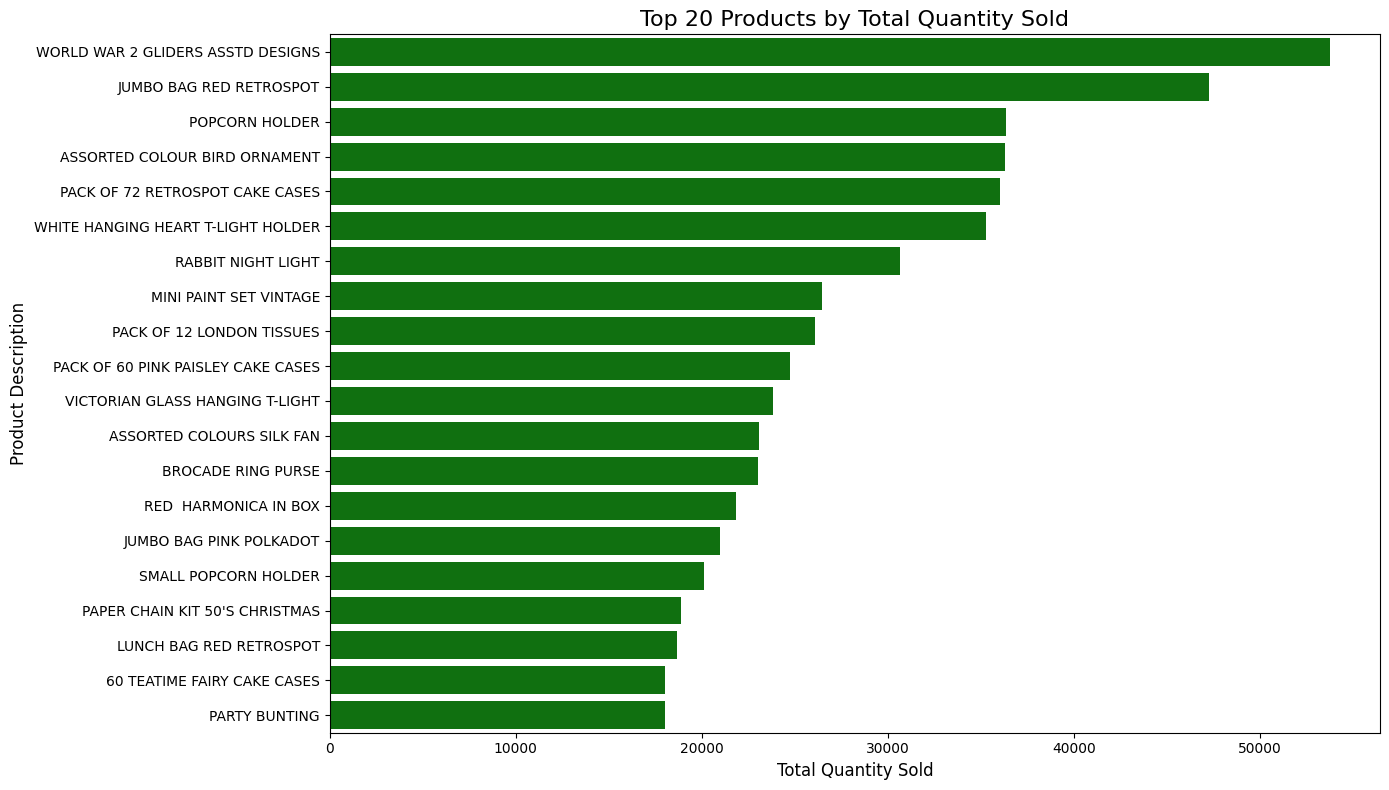

In [ ]:
top_products_quantity_df = pd.read_sql_query(
    """SELECT
    Description,
    SUM(Quantity) AS total_quantity
    FROM online_sales
    GROUP BY Description
    ORDER BY SUM(Quantity) DESC
    LIMIT 20;""",
    conn
)

# Plotting the top 20 products by total quantity
plt.figure(figsize=(14, 8))
sns.barplot(x='total_quantity', y='Description', hue='Description', data=top_products_quantity_df, palette=['green'], legend=False)
plt.title('Top 20 Products by Total Quantity Sold', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()

**Insights**

Product sales volume was led by `WORLD WAR 2 GLIDERS ASSTD DESIGNS` (53,751 units), followed by `JUMBO BAG RED RETROSPOT` (47,256 units) and `POPCORN HOLDER` (36,322 units). The ranking differs substantially from the top revenue-generating products, indicating that high sales volume does not necessarily translate into high revenue. Several products, including `JUMBO BAG RED RETROSPOT`, `WHITE HANGING HEART T-LIGHT HOLDER`, and `RABBIT NIGHT LIGHT`, performed strongly in both revenue and quantity sold, demonstrating both popularity and commercial value. Additionally, multiple Retrospot-themed products ranked among the top sellers, suggesting strong customer demand for this product family. Overall, the retailer's sales appear to be driven by a mix of high-volume, low-priced items and premium products that generate significant revenue despite lower sales quantities.

In [ ]:
# What is total_number of registered customers

%%sql

SELECT
COUNT(DISTINCT CustomerID) AS total_number_of_registered_customers
FROM online_sales
WHERE CustomerID IS NOT NULL;

 * sqlite:///my_data.db
Done.


total_number_of_registered_customers
4371


In [ ]:
# Most frequent registered customers

%%sql

SELECT
CustomerID,
COUNT(*) AS total_count
FROM online_sales
WHERE CustomerType = 'Registered'
GROUP BY CustomerID
ORDER BY COUNT(*) DESC
LIMIT 20;

 * sqlite:///my_data.db
Done.


CustomerID,total_count
17841.0,7812
14911.0,5896
14096.0,5128
12748.0,4458
14606.0,2759
15311.0,2478
14646.0,2081
13089.0,1853
13263.0,1667
14298.0,1640


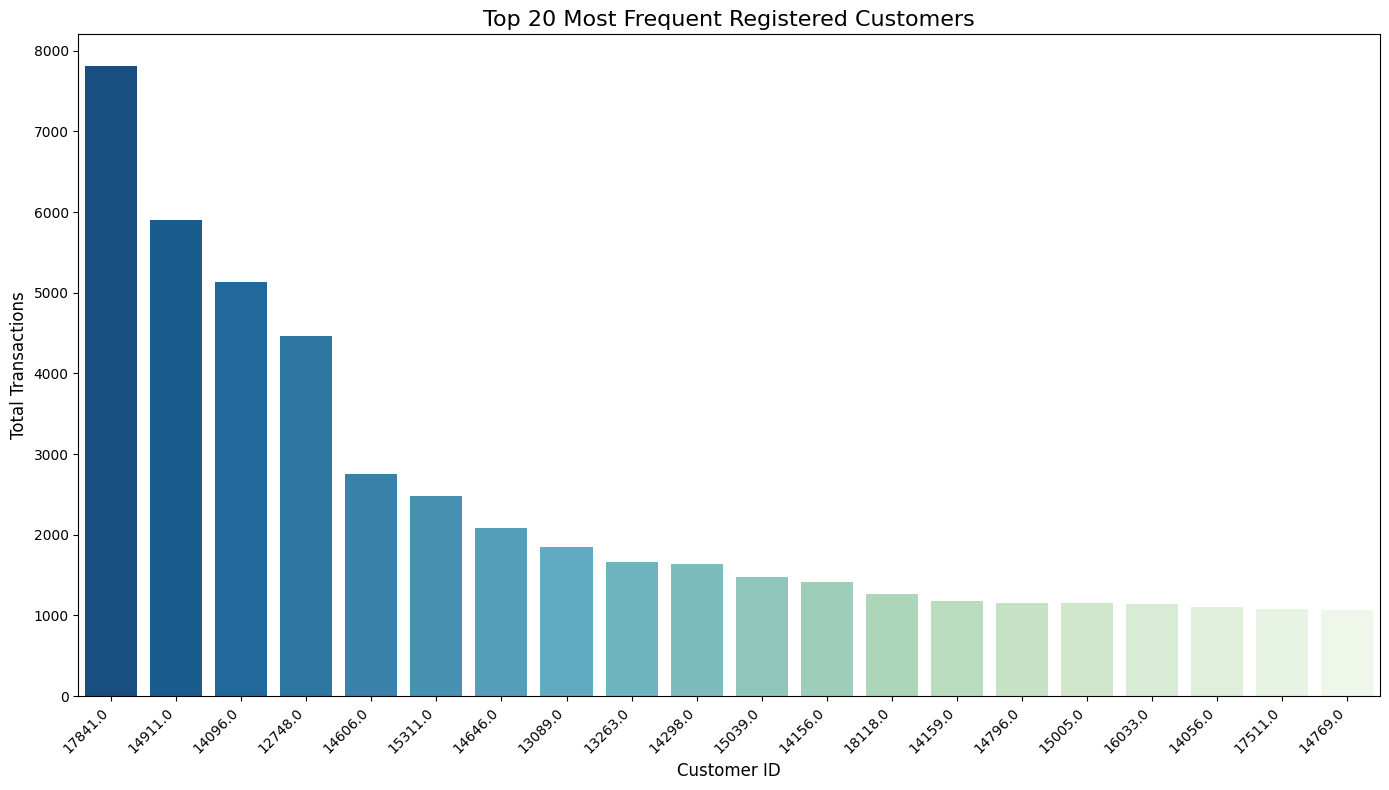

In [ ]:
most_frequent_customers_df = pd.read_sql_query(
    """SELECT
    CustomerID,
    COUNT(*) AS total_count
    FROM online_sales
    WHERE CustomerType = 'Registered'
    GROUP BY CustomerID
    ORDER BY COUNT(*) DESC
    LIMIT 20;""",
    conn
)

# Convert CustomerID to string for better display on x-axis
most_frequent_customers_df['CustomerID'] = most_frequent_customers_df['CustomerID'].astype(str)

# Plotting the most frequent registered customers
plt.figure(figsize=(14, 8))
sns.barplot(x='CustomerID', y='total_count', data=most_frequent_customers_df, palette='GnBu_r', hue='CustomerID', legend=False)
plt.title('Top 20 Most Frequent Registered Customers', fontsize=16)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights**

Customer 17841 generated the highest number of transaction records **(7,812)**, indicating extensive purchasing activity and a large variety of products purchased. This metric reflects transaction volume rather than purchase frequency and may be influenced by larger basket sizes or wholesale purchasing behavior.

In [ ]:
# One time vs repeated time customers

%%sql

WITH customer_orders AS (
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS OrderCount
FROM online_sales
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
)

SELECT
    CASE
        WHEN OrderCount = 1 THEN 'One-Time'
        ELSE 'Repeat'
    END AS CustomerType,
    COUNT(*) AS Customers
FROM customer_orders
GROUP BY CustomerType;

 * sqlite:///my_data.db
Done.


CustomerType,Customers
One-Time,1312
Repeat,3059


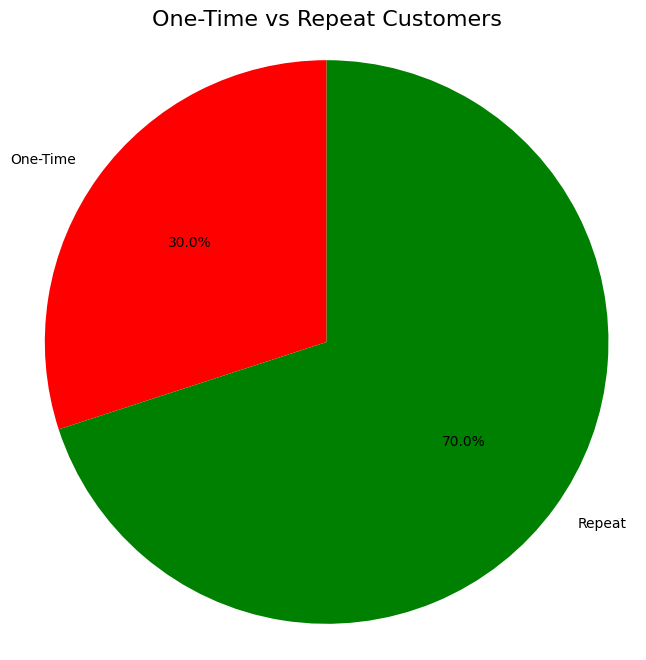

In [ ]:
one_time_vs_repeat_df = pd.read_sql_query(
    """WITH customer_orders AS (
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS OrderCount
    FROM online_sales
    WHERE CustomerID IS NOT NULL
    GROUP BY CustomerID
    )

    SELECT
        CASE
            WHEN OrderCount = 1 THEN 'One-Time'
            ELSE 'Repeat'
        END AS CustomerType,
        COUNT(*) AS Customers
    FROM customer_orders
    GROUP BY CustomerType;""",
    conn
)

# Define custom colors: red for 'One-Time' and green for 'Repeat'
# Ensure the order matches the order of CustomerType in the DataFrame
custom_colors = ['red', 'green']

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    one_time_vs_repeat_df['Customers'],
    labels=one_time_vs_repeat_df['CustomerType'],
    autopct='%1.1f%%', # Format for percentage labels
    startangle=90,
    colors=custom_colors
)
plt.title('One-Time vs Repeat Customers', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

**Insights**

Customer purchasing behavior was dominated by repeat buyers. Of the 4,371 registered customers, 3,059 (70%) placed more than one order, while 1,312 (30%) made only a single purchase. The high proportion of repeat customers suggests strong customer loyalty and indicates that **retention plays an important role in overall business performance.**

In [ ]:
# Customer Distribution by country

%%sql

SELECT
    Country,
    COUNT(DISTINCT CustomerID) AS Customers
FROM online_sales
GROUP BY Country
ORDER BY Customers DESC;

 * sqlite:///my_data.db
Done.


Country,Customers
United Kingdom,3949
Germany,95
France,87
Spain,31
Belgium,25
Switzerland,21
Portugal,19
Italy,15
Finland,12
Austria,11


/tmp/ipykernel_54810/2910412406.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customers', y='Country', data=top_10_countries, palette='viridis')


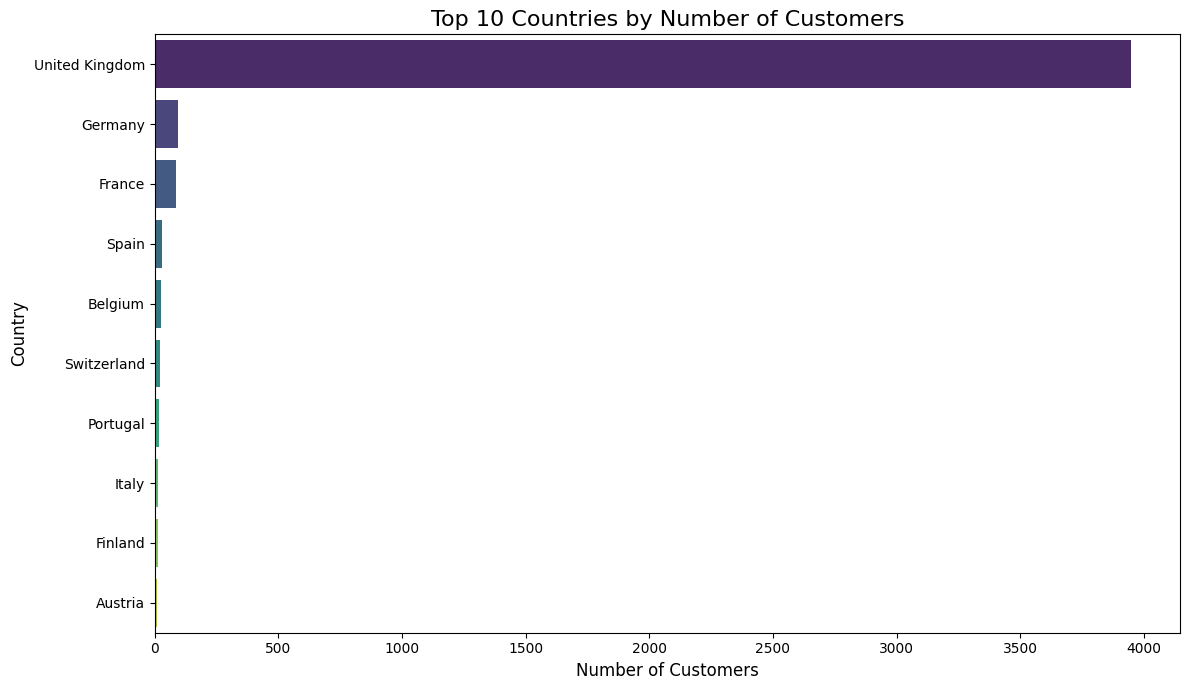

In [ ]:
customer_by_country_df = pd.read_sql_query(
    """SELECT
        Country,
        COUNT(DISTINCT CustomerID) AS Customers
    FROM online_sales
    GROUP BY Country
    ORDER BY Customers DESC;""",
    conn
)

# Select the top 10 countries
top_10_countries = customer_by_country_df.head(10)

# Plotting the top 10 countries by customers
plt.figure(figsize=(12, 7))
sns.barplot(x='Customers', y='Country', data=top_10_countries, palette='viridis')
plt.title('Top 10 Countries by Number of Customers', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

***Insights***

The customer base is heavily concentrated in the United Kingdom, which accounts for 3,949 customers (90.3% of all registered customers). International customers represent only 9.7% of the customer base but span more than 30 countries, demonstrating broad global reach. Germany and France emerged as the largest international markets by customer count, while countries such as the Netherlands, EIRE, and Australia generated substantial revenue despite relatively small customer bases

## Advanced Analysis (Answering Stakeholders questions)

### Q1. Does seasonality behave the same way across local and international markets?

In [ ]:
# UK Sales Seasonality

%%sql

SELECT
strftime('%Y-%m', InvoiceDate) AS year_month,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
WHERE Country = 'United Kingdom'
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY strftime('%Y-%m', InvoiceDate);


 * sqlite:///my_data.db
Done.


year_month,total_revenue
2010-12,674615.86
2011-01,432995.4
2011-02,407256.67
2011-03,558458.89
2011-04,441414.76
2011-05,595250.39
2011-06,553330.21
2011-07,564406.02
2011-08,537870.9
2011-09,860104.36


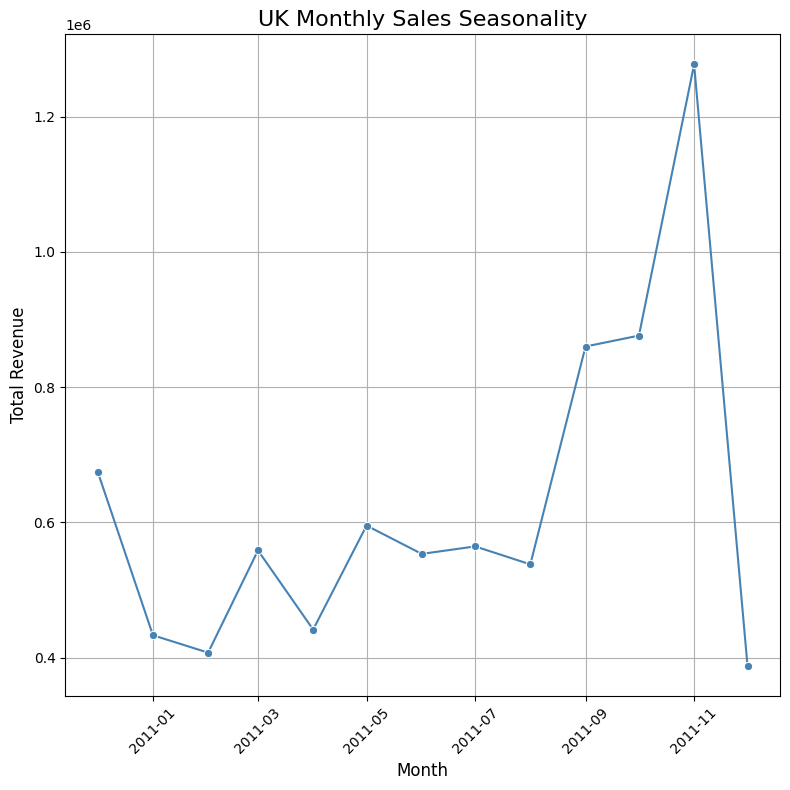

In [ ]:
uk_sales_seasonality_df = pd.read_sql_query(
    """SELECT
        strftime('%Y-%m', InvoiceDate) AS year_month,
        ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    WHERE Country = 'United Kingdom'
    GROUP BY strftime('%Y-%m', InvoiceDate)
    ORDER BY strftime('%Y-%m', InvoiceDate);""",
    conn
)

# Convert 'year_month' to datetime for proper plotting
uk_sales_seasonality_df['year_month'] = pd.to_datetime(uk_sales_seasonality_df['year_month'])

# Plotting the UK sales seasonality
plt.figure(figsize=(8, 8)) # Changed to a square figure size
sns.lineplot(data=uk_sales_seasonality_df, x='year_month', y='total_revenue', marker='o', color='steelblue') # Changed color to 'steelblue'
plt.title('UK Monthly Sales Seasonality', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# International Sales Seasonality

%%sql

SELECT
strftime('%Y-%m', InvoiceDate) AS year_month,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
WHERE Country != 'United Kingdom'
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY strftime('%Y-%m', InvoiceDate);

 * sqlite:///my_data.db
Done.


year_month,total_revenue
2010-12,72107.75
2011-01,125453.16
2011-02,89769.74
2011-03,123555.09
2011-04,50953.08
2011-05,126843.71
2011-06,136647.02
2011-07,115750.97
2011-08,143515.56
2011-09,157492.32


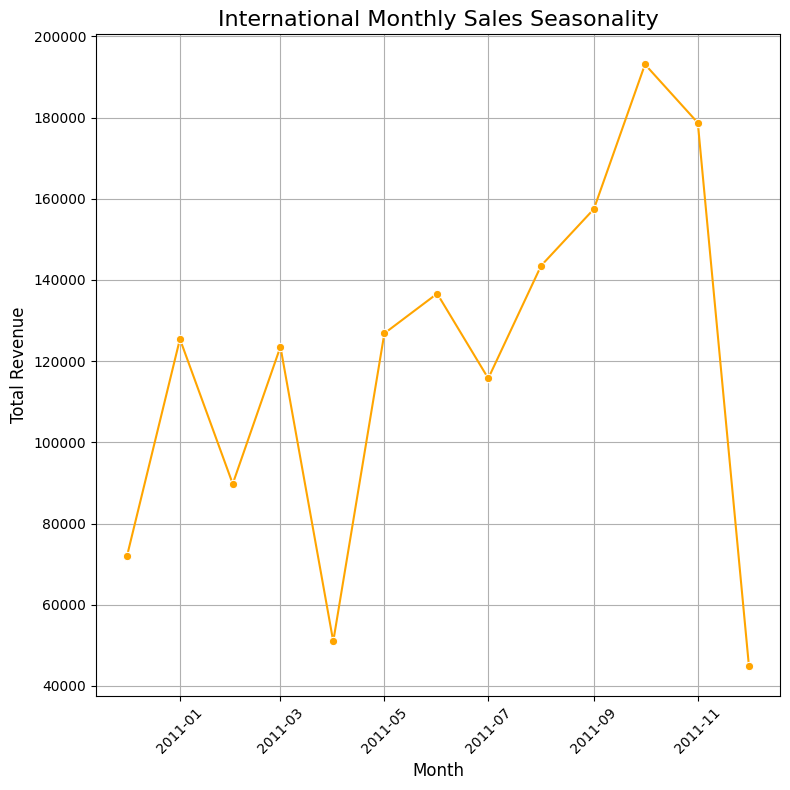

In [ ]:
international_sales_seasonality_df = pd.read_sql_query(
    """SELECT
        strftime('%Y-%m', InvoiceDate) AS year_month,
        ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    WHERE Country != 'United Kingdom'
    GROUP BY strftime('%Y-%m', InvoiceDate)
    ORDER BY strftime('%Y-%m', InvoiceDate);""",
    conn
)

# Convert 'year_month' to datetime for proper plotting
international_sales_seasonality_df['year_month'] = pd.to_datetime(international_sales_seasonality_df['year_month'])

# Plotting the international sales seasonality
plt.figure(figsize=(8, 8)) # Make the chart square
sns.lineplot(data=international_sales_seasonality_df, x='year_month', y='total_revenue', marker='o', color='orange')
plt.title('International Monthly Sales Seasonality', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***Insights***

* International markets peak in October, a full month earlier than the UK’s November peak, driven by global buyers securing inventory ahead of holiday shipping constraints.
* Furthermore, while the UK suffers from a severe post-holiday slump in January, international sales buck the trend entirely with a massive demand surge.

***Recommandation***

To maximize profitability, the business must immediately decouple its strategies: target international wholesale and promotional campaigns early in the autumn, and use international channels as a high-performing clearance vehicle for excess stock every January.

### Q2. Are we having revenue concentration risk? Which countries should we expand?

In [ ]:
# Revenue concentration risk and AOV

%%sql

WITH order_summary AS (
    SELECT
        InvoiceNo,
        CASE
            WHEN Country = 'United Kingdom' THEN 'UK'
            ELSE 'International'
        END AS Region,
        SUM(Revenue) AS OrderRevenue
    FROM online_sales
    GROUP BY InvoiceNo, Region
)

SELECT
    Region,
    ROUND(SUM(OrderRevenue), 2) AS TotalSales,
    COUNT(DISTINCT InvoiceNo) AS TotalOrders,
    ROUND(
        SUM(OrderRevenue) * 1.0 /
        COUNT(DISTINCT InvoiceNo),
        2
    ) AS AOV
FROM order_summary
GROUP BY Region;

 * sqlite:///my_data.db
Done.


Region,TotalSales,TotalOrders,AOV
International,1558878.77,2405,648.18
UK,8167128.18,21393,381.77


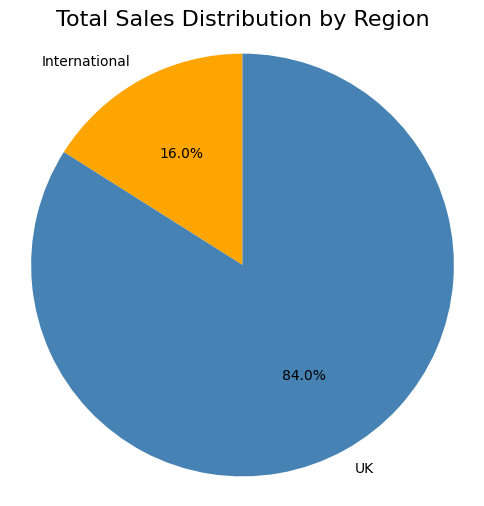


Detailed Revenue Concentration Metrics:


,Region,TotalSales,TotalOrders,AOV
0,International,1558878.77,2405,648.18
1,UK,8167128.18,21393,381.77


In [ ]:
revenue_concentration_df = pd.read_sql_query(
    """WITH order_summary AS (
        SELECT
            InvoiceNo,
            CASE
                WHEN Country = 'United Kingdom' THEN 'UK'
                ELSE 'International'
            END AS Region,
            SUM(Revenue) AS OrderRevenue
        FROM online_sales
        GROUP BY InvoiceNo, Region
    )

    SELECT
        Region,
        ROUND(SUM(OrderRevenue), 2) AS TotalSales,
        COUNT(DISTINCT InvoiceNo) AS TotalOrders,
        ROUND(
            SUM(OrderRevenue) * 1.0 /
            COUNT(DISTINCT InvoiceNo),
            2
        ) AS AOV
    FROM order_summary
    GROUP BY Region;""",
    conn
)

# Sort DataFrame by Region to ensure consistent color mapping
revenue_concentration_df = revenue_concentration_df.sort_values(by='Region', ascending=True)
colors = ['orange', 'steelblue']

# Create the pie chart for TotalSales
plt.figure(figsize=(6, 6))
plt.pie(
    revenue_concentration_df['TotalSales'],
    labels=revenue_concentration_df['Region'],
    autopct='%1.1f%%', # Format for percentage labels
    startangle=90,
    colors=colors
)
plt.title('Total Sales Distribution by Region', fontsize=16)
plt.axis('equal')
plt.show()

# Display the data as a table
print("\nDetailed Revenue Concentration Metrics:")
display(revenue_concentration_df)

In [ ]:
# Which countries should we expand?

%%sql

SELECT
Country,
ROUND(SUM(Revenue),2) AS total_revenue
FROM online_sales
WHERE Country != 'United Kingdom'
GROUP BY Country
ORDER BY ROUND(SUM(Revenue),2) DESC;

 * sqlite:///my_data.db
Done.


Country,total_revenue
Netherlands,284661.54
EIRE,262993.38
Germany,221509.47
France,197317.11
Australia,137009.77
Switzerland,56363.05
Spain,54756.03
Belgium,40910.96
Sweden,36585.41
Japan,35340.62


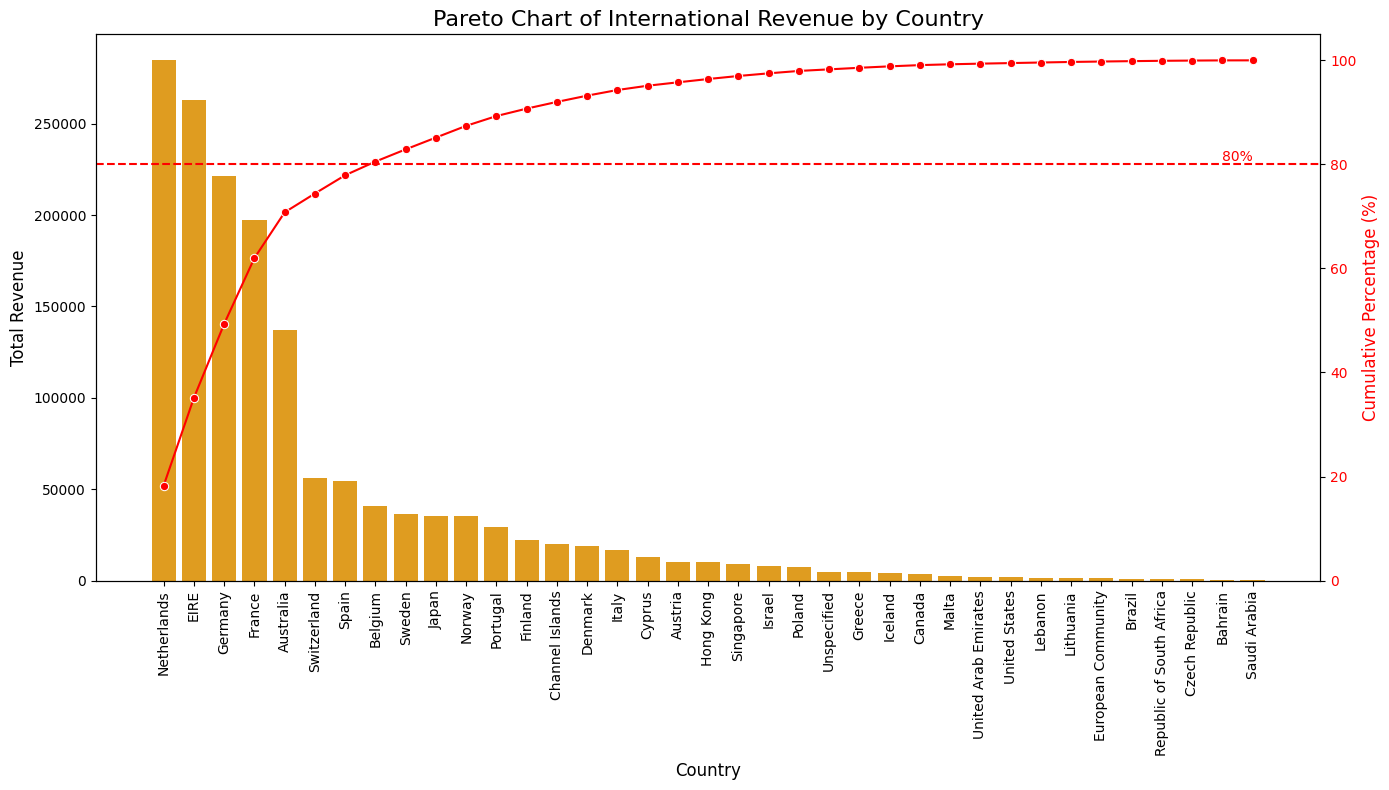

In [ ]:
import numpy as np

international_countries_revenue_df = pd.read_sql_query(
    """SELECT
    Country,
    ROUND(SUM(Revenue),2) AS total_revenue
    FROM online_sales
    WHERE Country != 'United Kingdom'
    GROUP BY Country
    ORDER BY ROUND(SUM(Revenue),2) DESC;""",
    conn
)

# Calculate cumulative percentage
international_countries_revenue_df['cumulative_revenue'] = international_countries_revenue_df['total_revenue'].cumsum()
international_countries_revenue_df['cumulative_percentage'] = 100 * international_countries_revenue_df['cumulative_revenue'] / international_countries_revenue_df['total_revenue'].sum()

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar plot for total revenue
sns.barplot(x='Country', y='total_revenue', data=international_countries_revenue_df, ax=ax1, color='orange')
ax1.set_xlabel('Country', fontsize=12)
ax1.set_ylabel('Total Revenue', fontsize=12)
ax1.tick_params(axis='x', rotation=90)

# Create a second y-axis for the cumulative percentage
ax2 = ax1.twinx()
sns.lineplot(x='Country', y='cumulative_percentage', data=international_countries_revenue_df, ax=ax2, color='red', marker='o', sort=False)
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # Set y-limit to slightly above 100% for better visualization

# Add 80% line
ax2.axhline(80, color='red', linestyle='--', label='80% Line')
ax2.text(len(international_countries_revenue_df)-1, 80, '80%', color='red', ha='right', va='bottom')

plt.title('Pareto Chart of International Revenue by Country', fontsize=16)
fig.tight_layout()
plt.show()

***Insights***

* The business currently faces revenue concentration risk because 84% of total sales come from the UK market. While international revenue has 71% higher AOV than UK, market is distributed across multiple countries, making it less risky than the UK dependence.

* According to Pareto principle, the strongest expansion opportunities are:
Netherlands, EIRE, Germany, France generating 62% of total international revenue and all countries are EU region.

***Recommandation***

* Reduce dependence on UK revenue from 84% toward 70–75%.
* Expand into EU countries with country-specific growth plans.

### Q3. We want to do exclusive VIPs marketing campaign. Identify the high-end customers based on their Recency, Frequency and Monetary.

In [ ]:
# Creating RFM table

%%sql

WITH base AS
(
  SELECT
    CustomerID,
    CASE
      WHEN Country = 'United Kingdom' THEN 'UK'
      ELSE 'International'
    END AS region,
    MIN(InvoiceDate) AS first_purchase_date,
    MAX(InvoiceDate) AS last_purchase_date,
    ROUND(SUM(Quantity), 2) AS total_quantity,
    COUNT(*) AS Frequency,
    ROUND(SUM(Revenue), 2) AS Monetary
  FROM online_sales
  WHERE CustomerID IS NOT NULL
  GROUP BY CustomerID, Country
),
max_date AS
(
  SELECT MAX(InvoiceDate) AS Maximum_date
  FROM online_sales
)
SELECT
    b.CustomerID,
    b.region,
    b.first_purchase_date,
    b.last_purchase_date,
    b.total_quantity,
    -- Calculate Recency using julianday for SQLite
    CAST(julianday(m.Maximum_date) - julianday(b.last_purchase_date) AS INTEGER) AS Recency,
    b.Frequency,
    b.Monetary,
    -- R_score Calculation
    CASE
        WHEN (julianday(m.Maximum_date) - julianday(b.last_purchase_date)) BETWEEN 0 AND 14 THEN 5
        WHEN (julianday(m.Maximum_date) - julianday(b.last_purchase_date)) BETWEEN 15 AND 45 THEN 4
        WHEN (julianday(m.Maximum_date) - julianday(b.last_purchase_date)) BETWEEN 46 AND 90 THEN 3
        WHEN (julianday(m.Maximum_date) - julianday(b.last_purchase_date)) BETWEEN 91 AND 180 THEN 2
        ELSE 1
    END AS R_score,
    -- F_score Calculation
    CASE
        WHEN b.Frequency <= 10 THEN 1
        WHEN b.Frequency <= 39 THEN 2
        WHEN b.Frequency <= 89 THEN 3
        WHEN b.Frequency <= 149 THEN 4
        ELSE 5
    END AS F_score,
    -- M_score Calculation
    CASE
        WHEN b.Monetary <= 500 THEN 1
        WHEN b.Monetary <= 2099 THEN 2
        WHEN b.Monetary <= 5000 THEN 3
        WHEN b.Monetary <= 14999 THEN 4
        ELSE 5
    END AS M_score
FROM base b
CROSS JOIN max_date m
WHERE R_score = 5 AND F_score = 5 AND M_score = 5; -- Remove this step to get all the customer lists with different score



 * sqlite:///my_data.db
Done.


CustomerID,region,first_purchase_date,last_purchase_date,total_quantity,Recency,Frequency,Monetary,R_score,F_score,M_score
12471.0,International,2010-12-02 00:00:00,2011-12-07 00:00:00,7953.0,2,530,18705.52,5,5,5
12748.0,UK,2010-12-01 00:00:00,2011-12-09 00:00:00,23749.0,0,4458,28405.56,5,5,5
12753.0,International,2010-12-12 00:00:00,2011-12-06 00:00:00,11250.0,3,230,21024.01,5,5,5
12921.0,UK,2010-12-01 00:00:00,2011-12-06 00:00:00,9454.0,3,741,16389.74,5,5,5
13081.0,UK,2010-12-03 00:00:00,2011-12-08 00:00:00,18929.0,1,1057,27964.48,5,5,5
13089.0,UK,2010-12-05 00:00:00,2011-12-07 00:00:00,30742.0,2,1853,57322.13,5,5,5
13098.0,UK,2011-01-26 00:00:00,2011-12-08 00:00:00,15911.0,1,605,28658.88,5,5,5
13408.0,UK,2010-12-01 00:00:00,2011-12-08 00:00:00,16119.0,1,501,27487.41,5,5,5
13694.0,UK,2010-12-01 00:00:00,2011-12-06 00:00:00,61899.0,3,584,62690.54,5,5,5
13767.0,UK,2010-12-01 00:00:00,2011-12-07 00:00:00,7258.0,2,399,16945.71,5,5,5


***RFM Table***

Calculated customers baseline RFM metrics against the dataset's maximum date using SQLite's `julianday` function, and maps those metrics onto a standardized 1-to-5 scoring system.

 High-end status is dynamically defined by specific operational thresholds:
  * buying within the last 14 days (Recency = 5),
 *  placing more than 149 orders (Frequency = 5),
 *  and spending over £14,999 (Monetary = 5).

  By applying the final WHERE clause to filter exclusively for customers who score a perfect 5 across all three dimensions, the query isolates the most active, loyal, and highest-spending tier, providing a highly refined list of premium targets tailored perfectly for an exclusive VIP marketing campaign.

### Q4. Analyze retention rates for customers and overall repeat purchase rate.

In [ ]:
# Customer retention cohort analysis

%%sql

WITH customer_first_purchase AS (
    -- Step 1: Isolate the birth/cohort month for every individual customer
    SELECT
        CustomerID,
        strftime('%Y-%m', MIN(InvoiceDate)) AS cohort_month
    FROM online_sales
    WHERE CustomerID IS NOT NULL
    GROUP BY CustomerID
),
customer_activity_months AS (
    -- Step 2: Extract all active transactional months per customer
    SELECT DISTINCT
        CustomerID,
        strftime('%Y-%m', InvoiceDate) AS activity_month
    FROM online_sales
    WHERE CustomerID IS NOT NULL
),
cohort_index_calc AS (
    -- Step 3: Calculate the chronological distance (index months) from birth month
    SELECT
        a.CustomerID,
        c.cohort_month,
        a.activity_month,
        -- SQLite date math using julianday to accurately calculate month differences
        (CAST(strftime('%Y', a.activity_month || '-01') AS INTEGER) - CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12 +
        (CAST(strftime('%m', a.activity_month || '-01') AS INTEGER) - CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER)) AS cohort_index
    FROM customer_activity_months a
    JOIN customer_first_purchase c ON a.CustomerID = c.CustomerID
)
-- Step 4: Group and aggregate unique customer counts per cohort index
SELECT
    cohort_month,
    cohort_index,
    COUNT(DISTINCT CustomerID) AS unique_customers
FROM cohort_index_calc
WHERE cohort_index >= 0
GROUP BY cohort_month, cohort_index
ORDER BY cohort_month, cohort_index;

 * sqlite:///my_data.db
Done.


cohort_month,cohort_index,unique_customers
2010-12,0,948
2010-12,1,362
2010-12,2,317
2010-12,3,367
2010-12,4,341
2010-12,5,376
2010-12,6,360
2010-12,7,336
2010-12,8,336
2010-12,9,374


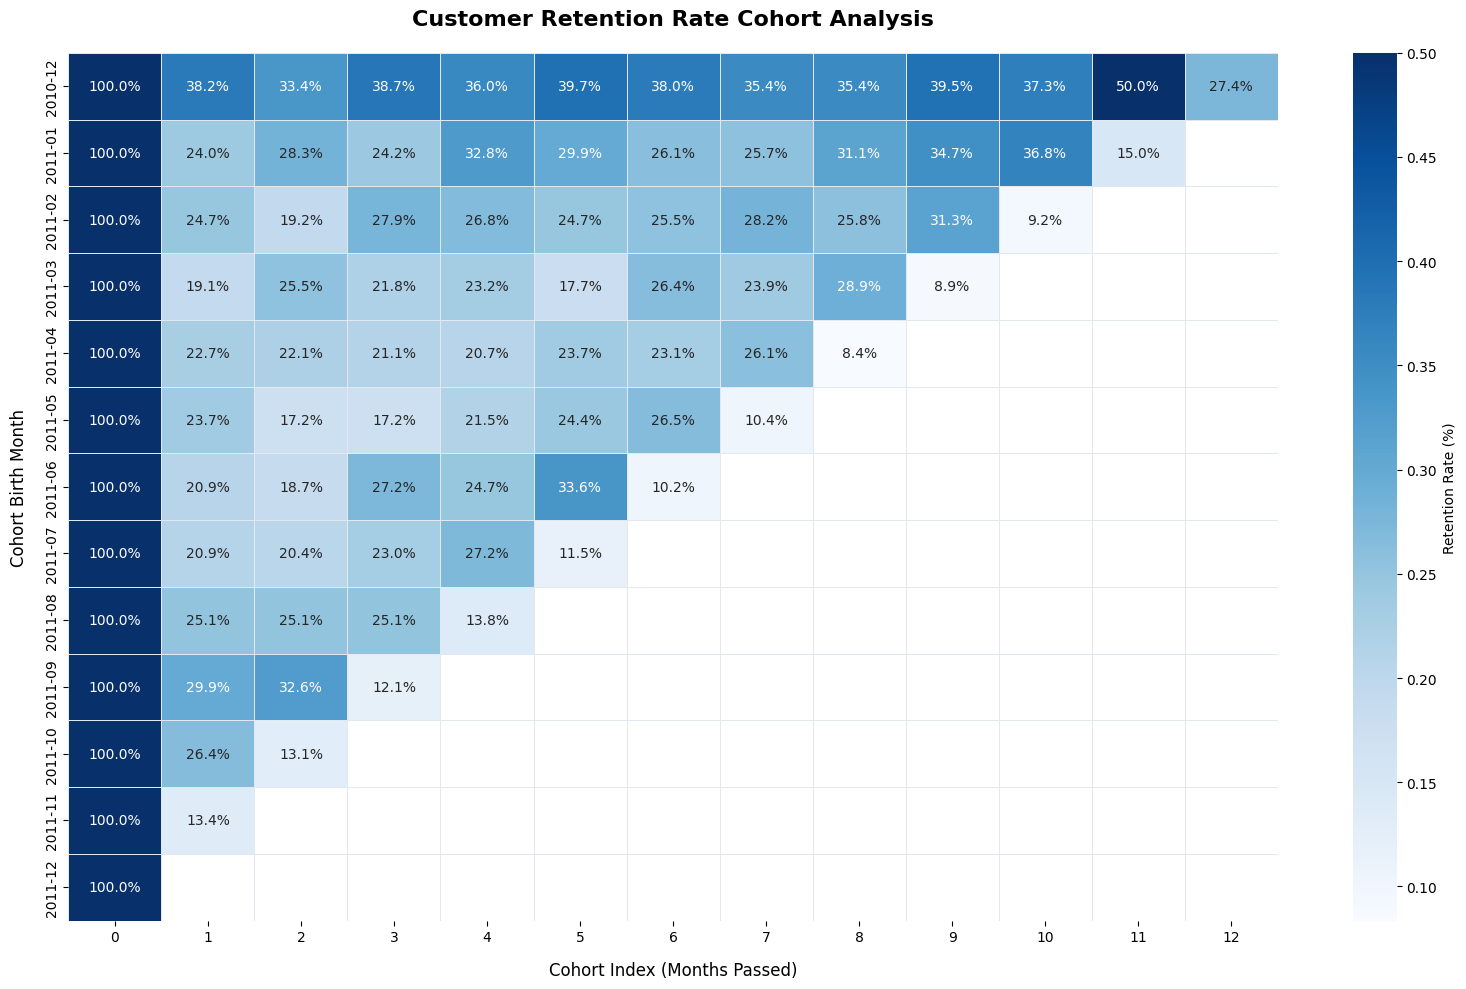

In [ ]:
cohort_raw = pd.read_sql_query("""
    WITH customer_first_purchase AS (
        SELECT CustomerID, strftime('%Y-%m', MIN(InvoiceDate)) AS cohort_month
        FROM online_sales
        WHERE CustomerID IS NOT NULL
        GROUP BY CustomerID
    ),
    customer_activity_months AS (
        SELECT DISTINCT CustomerID, strftime('%Y-%m', InvoiceDate) AS activity_month
        FROM online_sales
        WHERE CustomerID IS NOT NULL
    ),
    cohort_index_calc AS (
        SELECT
            a.CustomerID,
            c.cohort_month,
            (CAST(strftime('%Y', a.activity_month || '-01') AS INTEGER) - CAST(strftime('%Y', c.cohort_month || '-01') AS INTEGER)) * 12 +
            (CAST(strftime('%m', a.activity_month || '-01') AS INTEGER) - CAST(strftime('%m', c.cohort_month || '-01') AS INTEGER)) AS cohort_index
        FROM customer_activity_months a
        JOIN customer_first_purchase c ON a.CustomerID = c.CustomerID
    )
    SELECT cohort_month, cohort_index, COUNT(DISTINCT CustomerID) AS unique_customers
    FROM cohort_index_calc
    GROUP BY cohort_month, cohort_index;
""", conn)

# 2. Pivot the flat table into a broad analytical matrix
cohort_pivot = cohort_raw.pivot(index='cohort_month', columns='cohort_index', values='unique_customers')

# 3. Save initial cohort sizes (Month 0) to compute percentages
cohort_sizes = cohort_pivot.iloc[:, 0]

# 4. Convert absolute user counts into relative retention rates (decimals)
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

# 5. Build and render the heatmap visualization
plt.figure(figsize=(16, 10))
plt.title('Customer Retention Rate Cohort Analysis', fontsize=16, pad=20, weight='bold')

sns.heatmap(
    data=retention_matrix,
    annot=True,
    fmt='.1%',              # Displays values as clean percentages (e.g., 15.4%)
    cmap='Blues',           # Classic sequential blue grading
    vmax=0.5,               # Caps color intensity at 50% to make subtle variations stand out
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    linecolor='#e2e8f0'
)

# Label formatting to match image layout
plt.xlabel('Cohort Index (Months Passed)', fontsize=12, labelpad=12)
plt.ylabel('Cohort Birth Month', fontsize=12, labelpad=12)
plt.tight_layout()
plt.show()

In [ ]:
# Overall Retention Rate

%%sql

WITH customer_stats AS (
    SELECT
        CustomerID,
        COUNT(DISTINCT strftime('%Y-%m-%d', InvoiceDate)) AS active_days
    FROM online_sales
    WHERE CustomerID IS NOT NULL
    GROUP BY CustomerID
)
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN active_days > 1 THEN 1 ELSE 0 END) AS retained_customers,
    ROUND(
        CAST(SUM(CASE WHEN active_days > 1 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*) * 100,
        2
    ) || '%' AS overall_retention_rate
FROM customer_stats;

 * sqlite:///my_data.db
Done.


total_customers,retained_customers,overall_retention_rate
4371,2991,68.43%


***Insights***

Overall retention rate of 68.43% is primarily anchored by the exceptional long-term loyalty.

 December 2010 cohort, which consistently maintains a **33%** to **40%** retention rate and spikes to **50%** by Month 11.

 However, there is an immediate "Month 1 Cliff" where subsequent 2011 cohorts experience a sharp drop-off into the sub-**25%** range right after acquisition.

  Fortunately, customers who survive this initial month stabilize into a highly predictable recurring baseline (**20%** to **28%**) for the rest of their lifecycle, with explicit re-engagement surges occurring during the November holiday season.

  ***Recommandation***

  To maximize lifetime value, we must shift focus from top-of-funnel acquisition to aggressive Month 1 lifecycle marketing, while simultaneously deploying targeted Q4 win-back campaigns to capitalize on natural seasonal purchasing habits.